### **Problem 3.1**
Write a function for Python that simulates the roll of two standard, six-sided dice. Have the program roll the dice a large number of times and report the fraction of rolls that are each possible combination, 2–12. Compare your numbers with the probability of each possible roll that you calculate by hand.

In [159]:
import numpy as np

A = np.array([])
num = 100000
combos = np.array([[2,0],[3,0],[4,0],[5,0],[6,0],[7,0],[8,0],[9,0],[10,0],[11,0],[12,0]], dtype=float)
calculated_odds = np.array([[2,0],[3,0],[4,0],[5,0],[6,0],[7,0],[8,0],[9,0],[10,0],[11,0],[12,0]], dtype=float)
#print(combos)

for i in range(num):
    x = np.random.randint(low=1, high=7)
    y = np.random.randint(low=1, high=7)

    for j in range(2,13):
        if x + y == j:
            combos[j-2][1] += 1

for k in range(len(calculated_odds)):
    calculated_odds[k][1] = ( combos[k][1] / num )*100

print("These are the simulated odds of rolling two dice:")
print(calculated_odds)
print("This is compared to the actual odds of rolling two dice:")
actual_odds = np.array([[2,2.78],[3,5.56],[4,8.33],[5,11.11],[6,13.89],[7,16.67],[8,13.89],[9,11.11],[10,8.33],[11,5.56],[12,2.78]], dtype=float)
print(actual_odds)

These are the simulated odds of rolling two dice:
[[ 2.     2.774]
 [ 3.     5.536]
 [ 4.     8.222]
 [ 5.    11.217]
 [ 6.    13.934]
 [ 7.    16.645]
 [ 8.    13.921]
 [ 9.    11.227]
 [10.     8.188]
 [11.     5.521]
 [12.     2.815]]
This is compared to the actual odds of rolling two dice:
[[ 2.    2.78]
 [ 3.    5.56]
 [ 4.    8.33]
 [ 5.   11.11]
 [ 6.   13.89]
 [ 7.   16.67]
 [ 8.   13.89]
 [ 9.   11.11]
 [10.    8.33]
 [11.    5.56]
 [12.    2.78]]


### **Problem 3.2**
What is the value of x at the end of the following code snippet:

def sillyFunction(input_var):

x = 1.0

return input_var

x = 10.0


sillyFunction(x)

*the value of X at the end is 10.0. The function only returns the value it is given, and so to use the function to change x, you must say x = sillyFunction(x). In addition to this, the function sillyFunction does not interact with its input_var at all, it just returns what is imputted. Both of these cause x to remain unchanged*

### **Problem 3.3**
Write a function that takes as a parameter the name of the file, and a parameter that
gives the number of lines to read from the file. The function should open the file, read
the lines and print them to the screen, and then close the file.

In [ ]:
def print_file_lines(filename, num_lines):
    file = open(filename, 'r')
    for i in range(num_lines):
        line = file.readline()
        print(line)
    file.close()

### **Problem 4.2**
Ask the user for a matrix size, N. Print to the user a random matrix of size N by N. Then
print to the user the vector that contains the sum of each column.

In [149]:
N = int(input("Enter a matrix size N: "))

matrix = np.random.rand(N, N)
print("Random matrix N:\n", matrix)
column_sums = np.sum(matrix, axis=0)
print("Sum of each column:\n",column_sums)


Random matrix N:
 [[0.15655249 0.35193101 0.6287489 ]
 [0.62625819 0.50929396 0.01990399]
 [0.23788523 0.8023862  0.05496936]]
Sum of each column:
 [1.02069591 1.66361116 0.70362225]


### **Problem 4.5**
Ask the user for a vector size, N. Print to the user a random vector of size N where the
elements of N are from a normal distribution with mean 0 and standard deviation 1. To
generate this vector you should use np.random.normal. Then print the mean value
of the vector and the standard deviation. NumPy has a function that returns the mean
value and standard deviation: x.mean() and x.std(), where x is the name of a vector.

In [152]:
N = int(input("Enter a vector size N: "))

vector = np.random.normal(size=N)

print("Random vector N:\n", vector)

print("Mean of vector:", np.mean(vector))
print("Standard deviation of vector:", np.std(vector))

Random vector N:
 [ 1.16181652 -1.46081255  0.89971227]
Mean of vector: 0.20023874746696554
Standard deviation of vector: 1.1794047162060302


### **Problem 4.5**
Ask the user for a vector size, N. Print to the user two random vectors of size N; call these
vectors x and y. If we consider these vectors being the coordinates of points (xi,yi),
compute the matrix r that contains the distances between each point and each of other
points. This matrix will have elements
$$r_{ij} = \sqrt{(x_i-x_j)^2+(y_i-y_j)^2}$$
The diagonal of this matrix should be all zeros.

In [157]:
N = int(input("Enter a vector size N: "))
x = np.random.rand(N)
y = np.random.rand(N)
print("Vector x:\n", x)
print("Vector y:\n", y)

r = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        r[i, j] = np.sqrt((x[i] - x[j])**2 + (y[i] - y[j])**2)
print("Distance matrix r:\n", r)

Vector x:
 [0.53478614 0.09684343 0.53192593]
Vector y:
 [0.08233109 0.3379164  0.26954676]
Distance matrix r:
 [[0.         0.50706771 0.18723751]
 [0.50706771 0.         0.4404216 ]
 [0.18723751 0.4404216  0.        ]]


### **Chapter 4, Programming Project 1 - Inhour Equation**
The inhour equation (short for inverse hour) describes the growth or decay of the neutron
population in a reactor as described by the point kinetics equations. The equation relates the
reactivity, ρ, the mean generation time, Λ, the fraction of fission neutrons born from each of
six delayed neutron precursor groups, β_i, and the decay constant for those groups, λ_i. The
inhour equation is
$$ρ=s(Λ+\sum_{i=1}^6\frac{β_i}{s+λ_i})$$
The seven values of s that satisfy this equation are used to express the neutron population as
function of time, n(t), as
$$n(t)=\sum_{l=1}^7A_le^{s_lt}$$
The decay constant of a delayed neutron precursor group is related to the half-life for neutron
emission by the group is
$$λ_i=\frac{ln(2)}{t_{1/2}}$$
Common values of the necessary constants in this equation are: 
$$Λ = 5 × 10^{−5}s$$
$$β = [0.00021, 0.00142, 0.00128, 0.00257, 0.00075, 0.00027],$$
where the total delayed fraction β¯ = 0.0065, and
$$t_{1/2} = [56, 23, 6.2, 2.3, 0.61, 0.23]s$$
Using this data, plot the right-hand side of the inhour equation as a function of s, and plot
a horizontal line corresponding to ρ to graphically illustrate the roots of the inhour equation.
Do this for ρ = −1, 0, 0.1β,¯ β¯, and discuss the results. Make sure that the scale of your plot
makes sense given that there will be singularities in the plot.


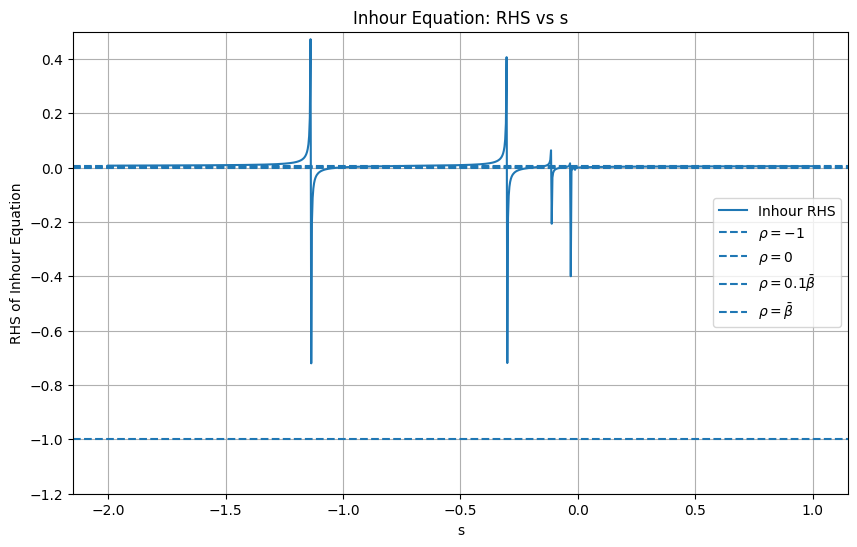

In [175]:
import matplotlib.pyplot as plt

# Constants
Lambda = 5e-5
beta = [0.00021, 0.00142, 0.00128, 0.00257, 0.00075, 0.00027]
beta_bar = 0.0065
t_half = [56, 23, 6.2, 2.3, 0.61, 0.23]

# Calculate decay constants
lambdas = [np.log(2) / t for t in t_half]

# Inhour equation right-hand side
def inhour_rhs(s):
    sum_term = 0
    for b, l in zip(beta, lambdas):
        sum_term += b / (s + l)
    return s * (Lambda + sum_term)

# s range (avoid singularities)
s = np.linspace(-2, 1, 1000)

# Reactivity values
rho_values = [-1, 0, 0.1 * beta_bar, beta_bar]
labels = [r'$ρ=-1$', r'$ρ=0$', r'$ρ=0.1\bar{β}$', r'$ρ=\bar{β}$']

plt.figure(figsize=(10, 6))
plt.plot(s, inhour_rhs(s), label='Inhour RHS')
for rho, label in zip(rho_values, labels):
    plt.axhline(y=rho, linestyle='--', label=label)

plt.xlabel('s')
plt.ylabel('RHS of Inhour Equation')
plt.title('Inhour Equation: RHS vs s')
plt.ylim(-1.2, .5)
plt.legend()
plt.grid(True)
plt.show()